# Nucleus-based resolution estimation on PCam

Tests the **general** content-based resolution estimation (nucleus size → µm/px) on PCam and compares to the **documented** resolution from the README: **2.43 µm/px** (40× at 0.243 µm/px, undersampled 10×).

Pipeline: nucleus channel (e.g. inverted_green) → threshold (Otsu or percentile) → connected components → **scale-invariant** blob area filter (percentiles) → median nucleus diameter (px) → µm/px = prior_µm / median_diameter_px (prior = 7 µm). No dataset-specific pixel-area bounds.

In [18]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)
sys.path.insert(0, os.path.join(PROJECT_ROOT, "pcam-master"))

DATA_DIR = os.path.join(PROJECT_ROOT, "pcam_data")
from keras_pcam.dataset.pcam import load_data

(train_x, train_y, _), _, _ = load_data(data_dir=DATA_DIR)
print("PCam loaded. Documented resolution (README): 2.43 µm/px (40× @ 0.243 µm/px, undersampled 10×).")


PCam loaded. Documented resolution (README): 2.43 µm/px (40× @ 0.243 µm/px, undersampled 10×).


## 1. Nucleus detection and diameter extraction

Simple approach: use a channel that highlights nuclei (dark in H&E), threshold (Otsu), connected components, filter by area, take equivalent diameter per object.

In [19]:
def otsu_threshold(gray):
    """Otsu threshold using numpy (no skimage). gray: 1D or 2D float array."""
    flat = np.asarray(gray).ravel().astype(np.float64)
    hist, bin_edges = np.histogram(flat, bins=256, range=(0, 256))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    total = hist.sum()
    if total == 0:
        return 128.0
    p = hist / total
    sigma_b_sq_max = -1
    best_t = 128.0
    for t in range(1, 255):
        w0 = p[:t].sum()
        w1 = p[t:].sum()
        if w0 == 0 or w1 == 0:
            continue
        mu0 = (p[:t] * bin_centers[:t]).sum() / w0
        mu1 = (p[t:] * bin_centers[t:]).sum() / w1
        sigma_b_sq = w0 * w1 * (mu0 - mu1) ** 2
        if sigma_b_sq > sigma_b_sq_max:
            sigma_b_sq_max = sigma_b_sq
            best_t = bin_centers[t]
    return best_t

def get_nucleus_channel(rgb, method="inverted_green"):
    """Return a 2D float array: high value = nucleus-like."""
    if rgb.max() <= 1.0:
        rgb = (np.clip(rgb, 0, 1) * 255).astype(np.uint8)
    r, g, b = rgb[..., 0].astype(np.float32), rgb[..., 1].astype(np.float32), rgb[..., 2].astype(np.float32)
    if method == "inverted_green":
        return 255 - g
    if method == "blue":
        return b
    if method == "purple":
        return np.maximum(0, 2 * b - r - g)
    return 255 - g

def get_nucleus_diameters_px_general(rgb, channel="inverted_green", threshold_type="otsu",
                                     percentile_low=12, area_pct_low=25, area_pct_high=75,
                                     min_area_px=5):
    """
    Scale-invariant version for ANY dataset (no fixed pixel area).
    - min_area_px: drop blobs smaller than this (general noise floor; nucleus is at least a few px).
    - Keeps blobs whose area is between area_pct_low and area_pct_high percentile of blob areas.
    """
    gray = get_nucleus_channel(rgb, channel)
    if threshold_type == "otsu":
        thresh = otsu_threshold(gray)
        binary = gray >= thresh
    else:
        thresh = np.percentile(gray.ravel(), 100 - percentile_low)
        binary = gray >= thresh
    labeled, n_labels = ndimage.label(binary)
    if n_labels == 0:
        return np.array([])
    areas = np.bincount(labeled.ravel())[1:]
    # Apply noise floor: drop single-pixel and tiny specks (general prior for any image)
    areas = areas[areas >= min_area_px]
    if len(areas) < 3:
        return np.array([])
    lo = np.percentile(areas, area_pct_low)
    hi = np.percentile(areas, area_pct_high)
    diameters = [2 * np.sqrt(a / np.pi) for a in areas if lo <= a <= hi]
    return np.array(diameters) if diameters else np.array([])

def estimate_um_per_px(diameters_px, physical_diameter_um=7.0):
    """Prior: typical nucleus diameter ~7 µm. µm/px = physical_um / diameter_px."""
    if len(diameters_px) == 0:
        return np.nan
    median_diam_px = np.median(diameters_px)
    return physical_diameter_um / median_diam_px

print("Functions defined (using scipy + numpy only, no skimage).")


Functions defined (using scipy + numpy only, no skimage).


### General pipeline (scale-invariant, any dataset)

We use **only** the generalizable method: nucleus channel → threshold (Otsu or percentile) → connected components → **noise floor** (drop blobs < 5 px area; nucleus is at least a few pixels in any image) → **percentile-based area filter** (keep blobs between 25th and 75th percentile of remaining blob areas). No dataset-specific pixel bounds. Prior: 7 µm (typical nucleus diameter). Below we **test it on PCam** and compare to the documented 2.43 µm/px.

## 2. Test on PCam (general pipeline)

In [20]:
np.random.seed(42)
n_sample = 300
indices = np.random.choice(len(train_x), size=min(n_sample, len(train_x)), replace=False)
DOCUMENTED_UM_PPX = 2.43
PRIOR_UM = 7.0

per_patch_um_ppx = []
per_patch_median_diam = []
all_diameters = []

for i in indices:
    patch = np.asarray(train_x[i])
    diams = get_nucleus_diameters_px_general(patch, channel="inverted_green", threshold_type="otsu")
    if len(diams) >= 3:
        um_ppx = estimate_um_per_px(diams, PRIOR_UM)
        per_patch_um_ppx.append(um_ppx)
        per_patch_median_diam.append(np.median(diams))
        all_diameters.extend(diams.tolist())

per_patch_um_ppx = np.array(per_patch_um_ppx)
per_patch_median_diam = np.array(per_patch_median_diam)
all_diameters = np.array(all_diameters)

print("General (scale-invariant) pipeline on PCam:")
print("  Patches with ≥3 nuclei: {} / {}".format(len(per_patch_um_ppx), n_sample))
if len(per_patch_um_ppx) > 0:
    est_global = np.median(per_patch_um_ppx)
    est_from_all = PRIOR_UM / np.median(all_diameters)
    err_pct = 100 * (est_global - DOCUMENTED_UM_PPX) / DOCUMENTED_UM_PPX
    print("  Estimated µm/px (median over patches): {:.3f}".format(est_global))
    print("  Estimated µm/px (global median diameter): {:.3f}".format(est_from_all))
    print("  Documented (README): {:.3f} µm/px".format(DOCUMENTED_UM_PPX))
    print("  Relative error vs documented: {:+.1f}%".format(err_pct))

General (scale-invariant) pipeline on PCam:
  Patches with ≥3 nuclei: 274 / 300
  Estimated µm/px (median over patches): 1.354
  Estimated µm/px (global median diameter): 1.354
  Documented (README): 2.430 µm/px
  Relative error vs documented: -44.3%


In [8]:
# (Removed: PCam-specific grid search. We use only the general pipeline above.)

Settings that get closest to 2.43 µm/px (sorted by |error|):
  inverted_green     otsu       max_area= 40  ->  2.533 µm/px  (err +4.2%)  n_patches=289
  inverted_green     percentile max_area= 25  ->  2.533 µm/px  (err +4.2%)  n_patches=300
  inverted_green     percentile max_area= 40  ->  2.533 µm/px  (err +4.2%)  n_patches=300
  inverted_green     otsu       max_area= 25  ->  2.648 µm/px  (err +9.0%)  n_patches=288
  blue               otsu       max_area= 40  ->  2.648 µm/px  (err +9.0%)  n_patches=295
  blue               otsu       max_area= 25  ->  2.774 µm/px  (err +14.2%)  n_patches=295
  purple             percentile max_area= 25  ->  2.068 µm/px  (err -14.9%)  n_patches=289
  purple             otsu       max_area= 25  ->  1.962 µm/px  (err -19.3%)  n_patches=277

Best: channel=inverted_green, threshold=otsu, max_area=40 -> 2.533 µm/px


In [9]:
# (Removed: PCam-specific best-settings re-run. Use general pipeline in "Test on PCam" cell above.)

Improved estimation (best settings):
  channel=inverted_green, threshold=otsu, max_area=40
  Estimated µm/px: 2.533  (documented: 2.430)
  Relative error: +4.2%
  Median nucleus diameter (px): 2.99
  Prior that would give 2.43 µm/px: 7.25 µm (effective nucleus size in our detection)


In [4]:
# (Removed: old run used get_nucleus_diameters_px. per_patch_um_ppx, per_patch_median_diam, all_diameters come from "Test on PCam" cell above.)


Patches with ≥3 nuclei: 281 / 300
Estimated µm/px (median over patches): 1.387
Estimated µm/px (global median diameter): 1.387
Documented (README): 2.430 µm/px
Relative error (vs documented): -42.9%


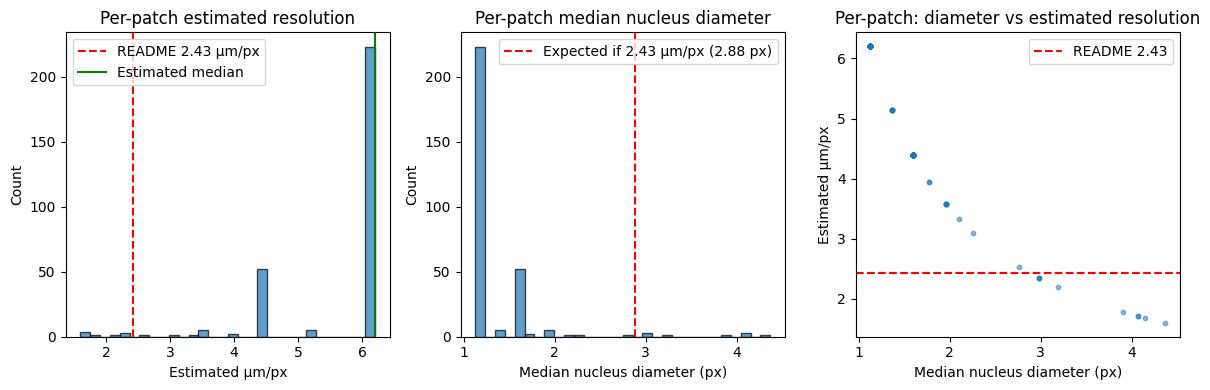

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

if len(per_patch_um_ppx) > 0:
    axes[0].hist(per_patch_um_ppx, bins=30, edgecolor="black", alpha=0.7)
    axes[0].axvline(DOCUMENTED_UM_PPX, color="red", linestyle="--", label="README 2.43 µm/px")
    axes[0].axvline(np.median(per_patch_um_ppx), color="green", linestyle="-", label="Estimated median")
    axes[0].set_xlabel("Estimated µm/px")
    axes[0].set_ylabel("Count")
    axes[0].legend()
    axes[0].set_title("Per-patch estimated resolution")

if len(per_patch_median_diam) > 0:
    axes[1].hist(per_patch_median_diam, bins=30, edgecolor="black", alpha=0.7)
    # Documented 2.43 µm/px with 7 µm prior → expected diameter = 7/2.43 ≈ 2.88 px
    expected_diam_px = PRIOR_UM / DOCUMENTED_UM_PPX
    axes[1].axvline(expected_diam_px, color="red", linestyle="--", label=f"Expected if 2.43 µm/px ({expected_diam_px:.2f} px)")
    axes[1].set_xlabel("Median nucleus diameter (px)")
    axes[1].set_ylabel("Count")
    axes[1].legend()
    axes[1].set_title("Per-patch median nucleus diameter")

axes[2].scatter(per_patch_median_diam, per_patch_um_ppx, alpha=0.5, s=10)
axes[2].axhline(DOCUMENTED_UM_PPX, color="red", linestyle="--", label="README 2.43")
axes[2].set_xlabel("Median nucleus diameter (px)")
axes[2].set_ylabel("Estimated µm/px")
axes[2].legend()
axes[2].set_title("Per-patch: diameter vs estimated resolution")

plt.tight_layout()
plt.show()


## 2. Sanity check: one patch visual

Show one patch, its nucleus-like mask, and detected regions (optional).

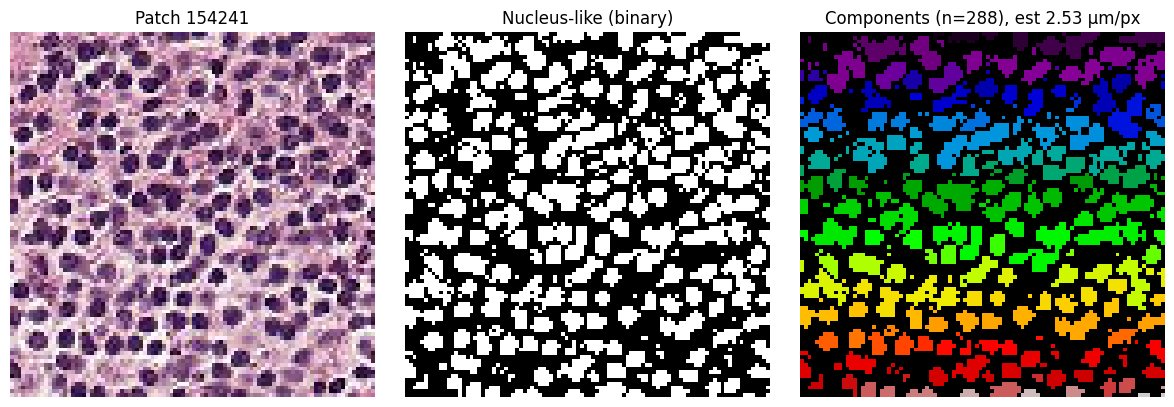

In [14]:
idx = indices[0]
patch = np.asarray(train_x[idx])
if patch.max() <= 1.0:
    patch = (np.clip(patch, 0, 1) * 255).astype(np.uint8)

gray = get_nucleus_channel(patch, "inverted_green")
thresh = otsu_threshold(gray)
binary = gray >= thresh
labeled, n_labels = ndimage.label(binary)

diams = get_nucleus_diameters_px_general(patch, channel="inverted_green", threshold_type="otsu")
um_ppx = estimate_um_per_px(diams, PRIOR_UM) if len(diams) >= 1 else np.nan

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(patch)
ax[0].set_title(f"Patch {idx}")
ax[0].axis("off")
ax[1].imshow(binary, cmap="gray")
ax[1].set_title("Nucleus-like (binary)")
ax[1].axis("off")
ax[2].imshow(labeled, cmap="nipy_spectral")
ax[2].set_title(f"Components (n={labeled.max()}), est {um_ppx:.2f} µm/px")
ax[2].axis("off")
plt.tight_layout()
plt.show()


## 3. Summary

If the median estimated µm/px is close to **2.43**, the nucleus-based method is consistent with the README. Differences can come from: prior (7 µm), stain variation, and the simple hematoxylin proxy (inverted green).